MILESTONE-2_Week 3 – Univariate & Bivariate Visual Analysis

In [1]:
# importing necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../Data/Processed/flights_2009_processed.csv")

df.head()

,FL_DATE,OP_CARRIER,OP_CARRIER_FL_NUM,ORIGIN,DEST,CRS_DEP_TIME,DEP_TIME,DEP_DELAY,TAXI_OUT,WHEELS_OFF,...,NAS_DELAY,SECURITY_DELAY,LATE_AIRCRAFT_DELAY,YEAR,MONTH,DAY,DAY_OF_WEEK,DEP_HOUR,ROUTE,SEASON
0,2009-07-26,XE,2235,ATL,IAH,1200,1155,-5.0,19.0,1214,...,0.0,0.0,0.0,2009,7,26,6,11,ATL-IAH,Summer
1,2009-05-04,AS,118,ANC,SEA,630,628,-2.0,12.0,640,...,0.0,0.0,0.0,2009,5,4,0,6,ANC-SEA,Spring
2,2009-06-28,MQ,4201,ORD,MKE,1405,1411,6.0,10.0,1421,...,0.0,0.0,0.0,2009,6,28,6,14,ORD-MKE,Summer
3,2009-06-04,WN,937,SAT,HRL,835,831,-4.0,9.0,840,...,0.0,0.0,0.0,2009,6,4,3,8,SAT-HRL,Summer
4,2009-06-11,MQ,3588,MOB,DFW,1720,1714,-6.0,10.0,1724,...,0.0,0.0,0.0,2009,6,11,3,17,MOB-DFW,Summer


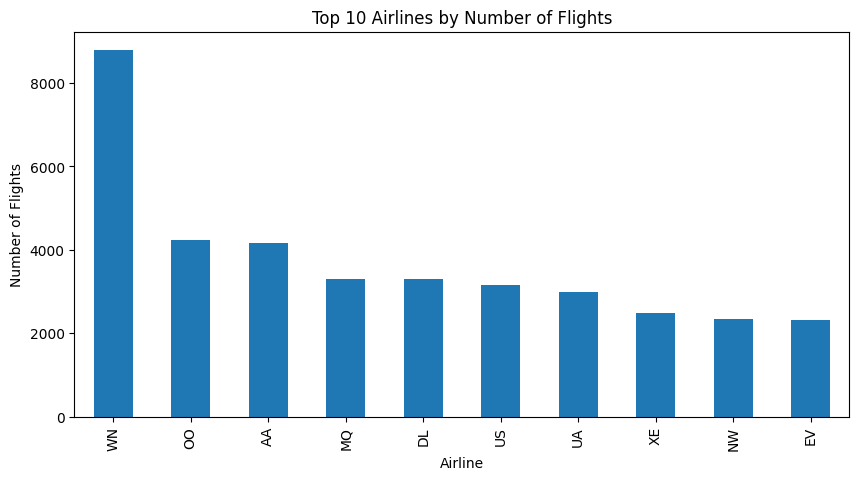

In [2]:
plt.figure(figsize=(10,5))
df['OP_CARRIER'].value_counts().head(10).plot(kind='bar')
plt.title("Top 10 Airlines by Number of Flights")
plt.xlabel("Airline")
plt.ylabel("Number of Flights")
plt.show()

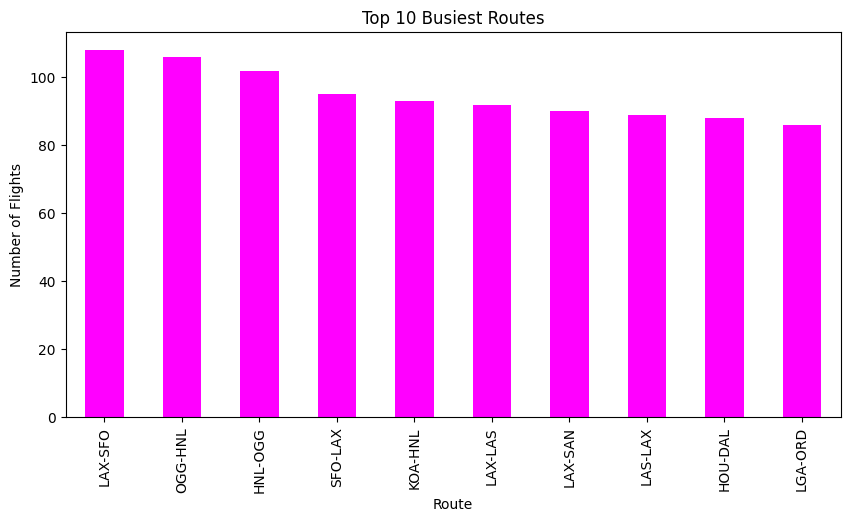

In [3]:
top_routes = df['ROUTE'].value_counts().head(10)

plt.figure(figsize=(10,5))
top_routes.plot(kind='bar' ,color='fuchsia')
plt.title("Top 10 Busiest Routes")
plt.xlabel("Route")
plt.ylabel("Number of Flights")
plt.show()

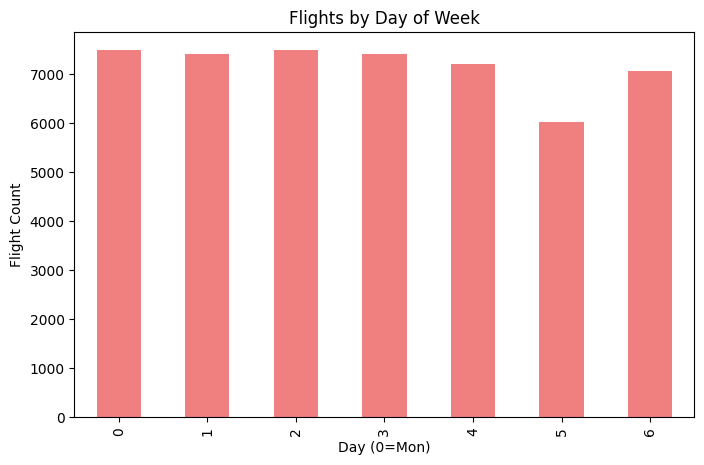

In [4]:
plt.figure(figsize=(8,5))
df['DAY_OF_WEEK'].value_counts().sort_index().plot(kind='bar',color='lightcoral')
plt.title("Flights by Day of Week")
plt.xlabel("Day (0=Mon)")
plt.ylabel("Flight Count")
plt.show()

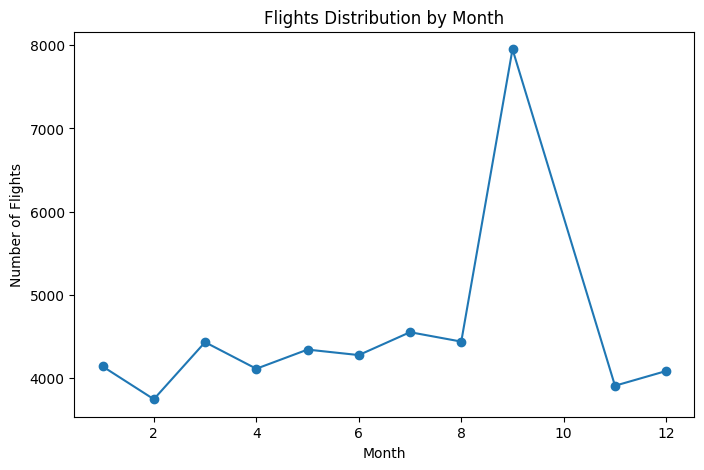

In [5]:
plt.figure(figsize=(8,5))
df['MONTH'].value_counts().sort_index().plot(kind='line', marker='o')
plt.title("Flights Distribution by Month")
plt.xlabel("Month")
plt.ylabel("Number of Flights")
plt.show()

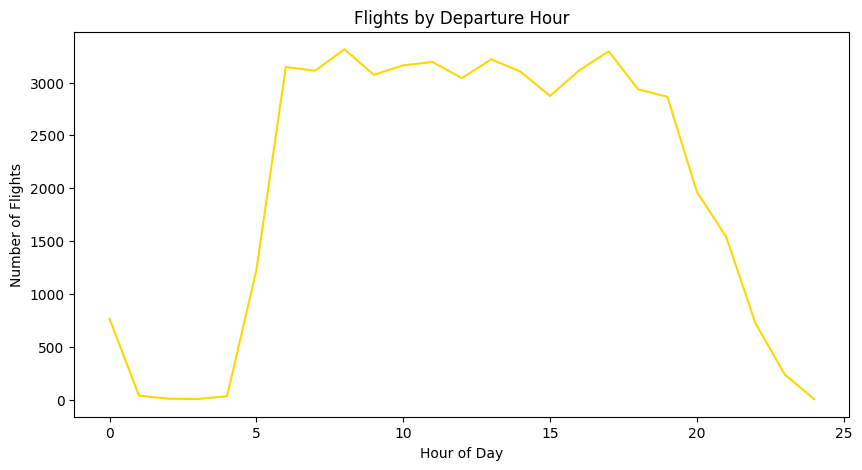

In [6]:
plt.figure(figsize=(10,5))
df['DEP_HOUR'].value_counts().sort_index().plot(kind='line',color='gold')
plt.title("Flights by Departure Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Flights")
plt.show()

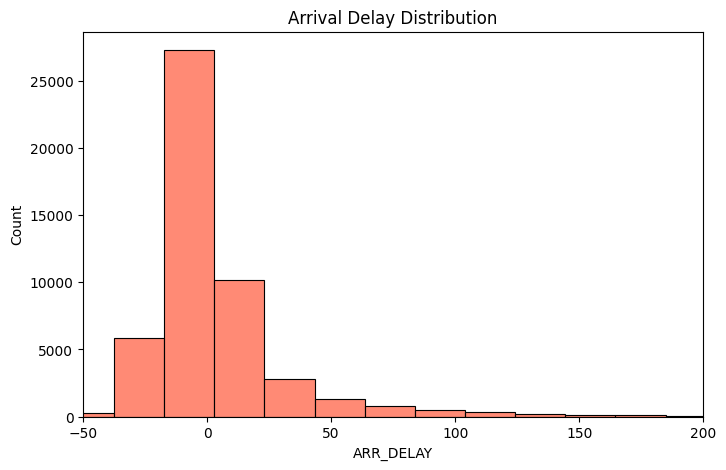

In [7]:
plt.figure(figsize=(8,5))
sns.histplot(df['ARR_DELAY'], bins=50,color='tomato')
plt.title("Arrival Delay Distribution")
plt.xlim(-50, 200)
plt.show()

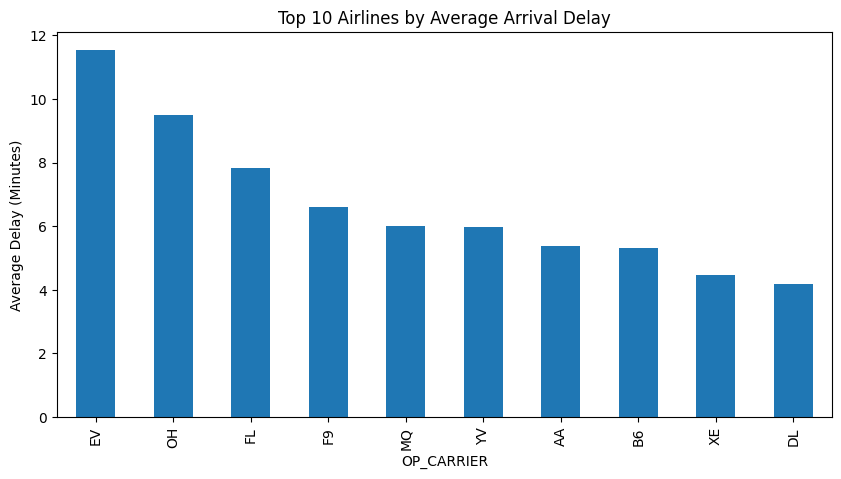

In [8]:
avg_delay = df.groupby('OP_CARRIER')['ARR_DELAY'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
avg_delay.plot(kind='bar')
plt.title("Top 10 Airlines by Average Arrival Delay")
plt.ylabel("Average Delay (Minutes)")
plt.show()

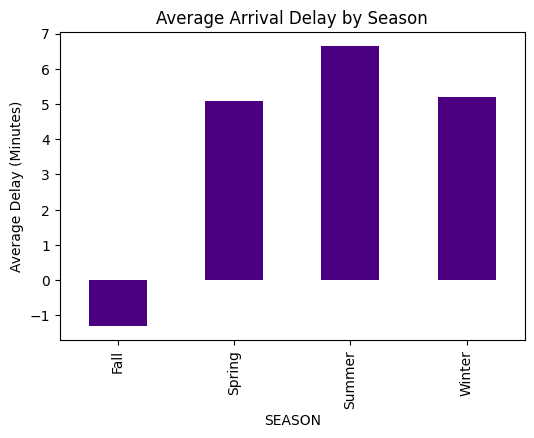

In [9]:
season_delay = df.groupby('SEASON')['ARR_DELAY'].mean()

plt.figure(figsize=(6,4))
season_delay.plot(kind='bar', color='indigo')
plt.title("Average Arrival Delay by Season")
plt.ylabel("Average Delay (Minutes)")
plt.show()

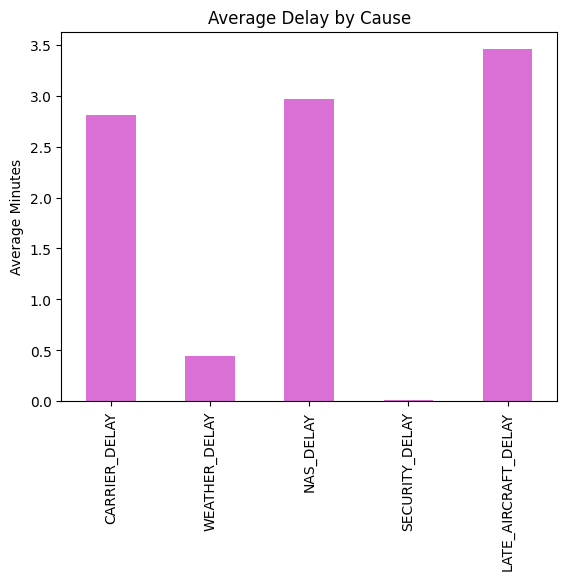

In [10]:
delay_types = [
    'CARRIER_DELAY',
    'WEATHER_DELAY',
    'NAS_DELAY',
    'SECURITY_DELAY',
    'LATE_AIRCRAFT_DELAY'
]

df[delay_types].mean().plot(kind='bar' , color='orchid')
plt.title("Average Delay by Cause")
plt.ylabel("Average Minutes")
plt.show()

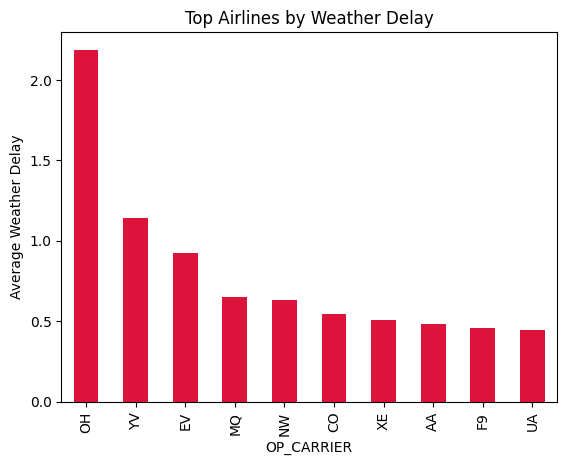

In [11]:
carrier_weather = df.groupby('OP_CARRIER')['WEATHER_DELAY'].mean().sort_values(ascending=False).head(10)

carrier_weather.plot(kind='bar' , color='crimson')
plt.title("Top Airlines by Weather Delay")
plt.ylabel("Average Weather Delay")
plt.show()

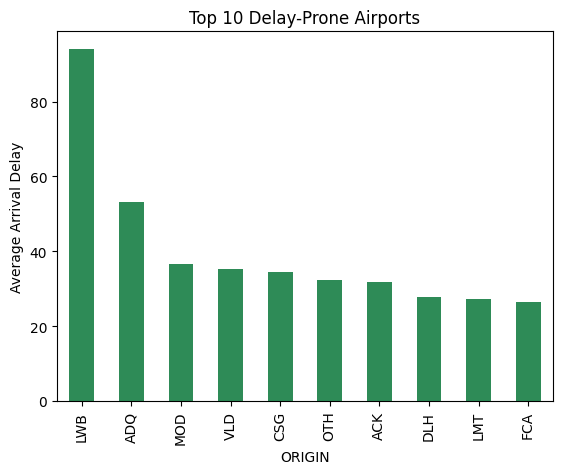

In [12]:
airport_delay = df.groupby('ORIGIN')['ARR_DELAY'].mean().sort_values(ascending=False).head(10)

airport_delay.plot(kind='bar', color='seagreen')
plt.title("Top 10 Delay-Prone Airports")
plt.ylabel("Average Arrival Delay")
plt.show()

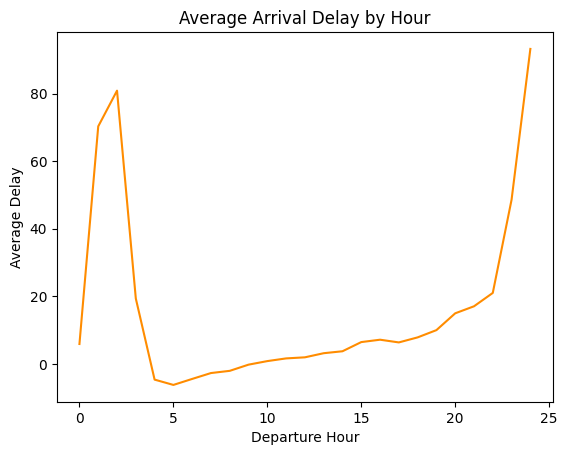

In [13]:
hour_delay = df.groupby('DEP_HOUR')['ARR_DELAY'].mean()

hour_delay.plot(kind='line', color='darkorange')
plt.title("Average Arrival Delay by Hour")
plt.xlabel("Departure Hour")
plt.ylabel("Average Delay")
sns.set_palette('tab10')
plt.show()

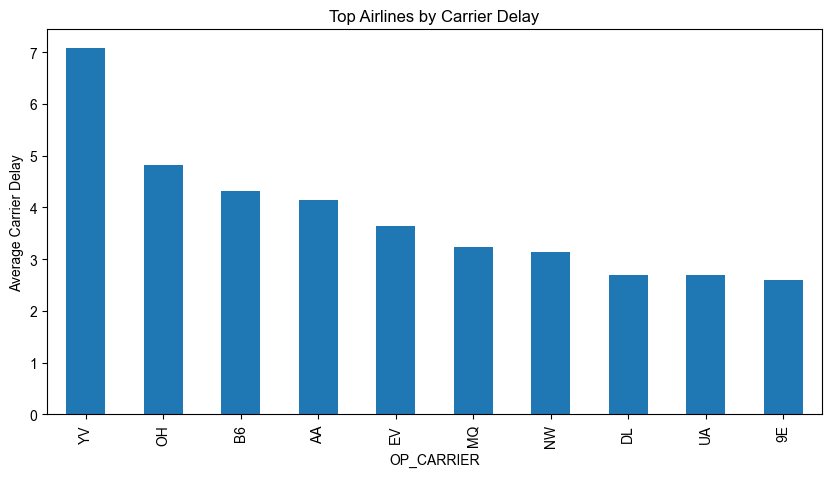

In [14]:
carrier_delay = df.groupby('OP_CARRIER')['CARRIER_DELAY'].mean().sort_values(ascending=False).head(10)

carrier_delay.plot(kind='bar', figsize=(10,5))
plt.title("Top Airlines by Carrier Delay")
plt.ylabel("Average Carrier Delay")
sns.set_style('whitegrid')
sns.set_palette('tab10')
plt.rcParams['figure.figsize']=(10,5)
plt.show()

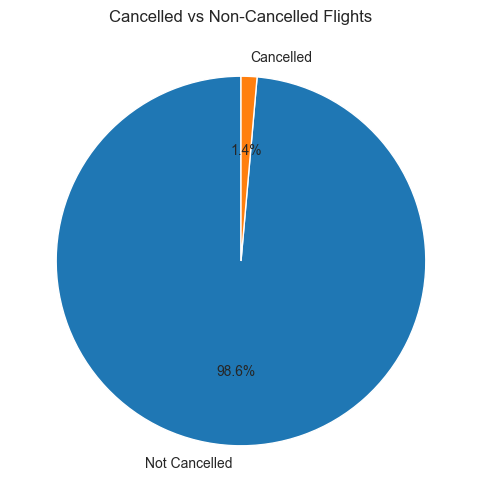

In [15]:
cancel_counts = df['CANCELLED'].value_counts()

labels = ['Not Cancelled', 'Cancelled']

plt.figure(figsize=(6,6))
plt.pie(cancel_counts, labels=labels, autopct='%1.1f%%', startangle=90)

plt.title("Cancelled vs Non-Cancelled Flights")
plt.show()

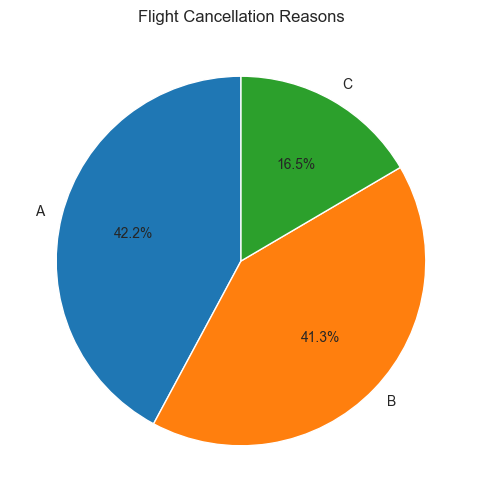

In [16]:
# Cancellation Reasons  for flights A=carrier, B=Weather, C=National air system
cancel_reason = df[df['CANCELLED'] == 1]['CANCELLATION_CODE'].value_counts()

plt.figure(figsize=(6,6))
plt.pie(cancel_reason, labels=cancel_reason.index, autopct='%1.1f%%', startangle=90)

plt.title("Flight Cancellation Reasons")
plt.show()